In [15]:
# packages
import pandas as pd
import hdbscan
import numpy as np
from hdbscan import approximate_predict
from joblib import dump, load
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
# import des données

FP = "../../data/features/behaviour_features.jsonl"
df = pd.read_json(FP, lines=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   features         951 non-null    object        
 1   vector           951 non-null    object        
 2   source           951 non-null    str           
 3   schema_version   951 non-null    float64       
 4   feature_version  951 non-null    float64       
 5   stored_at        951 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(2), object(2), str(1)
memory usage: 44.7+ KB


In [4]:
# dataframe from dict in features column
features = pd.DataFrame(df["features"].tolist())


In [5]:
features

,events_per_second,event_count,mean_dt,std_dt,min_dt,max_dt,burstiness,hover_count,click_count,purchase_count,...,unique_categories,category_diversity,product_entropy,category_entropy,scroll_events,total_scroll_distance,scroll_speed,scroll_std,large_scroll_ratio,hover_click_ratio
0,7.751938,5,0.161250,0.041245,0.100,0.211,0.255786,5,0,0,...,0,0.0,1.332179,0.0,0,0.000000,0.000000,0.000000,0.000000,5.0
1,33.123025,21,0.031700,0.050400,0.000,0.227,1.589921,3,0,0,...,0,0.0,1.098612,0.0,18,495.000000,780.757020,22.467878,0.000000,3.0
2,69.444495,15,0.015429,0.004578,0.000,0.021,0.296730,0,0,0,...,0,0.0,0.000000,0.0,15,224.000000,1037.037797,16.167732,0.000000,0.0
3,75.376839,15,0.014214,0.008537,0.000,0.033,0.600602,1,0,0,...,0,0.0,-0.000000,0.0,14,102.000000,512.562505,9.376479,0.000000,1.0
4,29.027571,20,0.036263,0.085991,0.000,0.400,2.371297,0,0,0,...,0,0.0,0.000000,0.0,20,219.000000,317.851900,9.409968,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1484,3.030303,2,0.660000,0.000000,0.660,0.660,0.000000,1,0,0,...,0,0.0,-0.000000,0.0,0,0.000000,0.000000,0.000000,0.000000,1.0
1485,74.918586,46,0.013644,0.006580,0.000,0.022,0.482244,2,0,0,...,0,0.0,0.693147,0.0,44,30647.759399,49914.930303,284.872918,0.727273,2.0
1486,78.521946,68,0.012925,0.006770,0.000,0.023,0.523761,2,0,0,...,0,0.0,0.693147,0.0,65,39119.363403,45172.478345,239.028093,0.507692,2.0
1487,10.000001,8,0.114286,0.124684,0.014,0.356,1.090989,1,0,0,...,0,0.0,-0.000000,0.0,7,1329.583740,1661.979774,239.591600,0.142857,1.0


In [12]:
# fusion avec l'autre jsonl appelé MN__pareil__
FP2 = "../../data/features/MNbehaviour_features.jsonl"
df2 = pd.read_json(FP2, lines=True)
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   features         597 non-null    object        
 1   vector           597 non-null    object        
 2   source           597 non-null    str           
 3   schema_version   597 non-null    float64       
 4   feature_version  597 non-null    float64       
 5   stored_at        597 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(2), object(2), str(1)
memory usage: 28.1+ KB


In [13]:
# transformation en DF
features2 = pd.DataFrame(df2["features"].tolist())
features2.head()

,events_per_second,event_count,mean_dt,std_dt,min_dt,max_dt,burstiness,hover_count,click_count,purchase_count,...,unique_categories,category_diversity,product_entropy,category_entropy,scroll_events,total_scroll_distance,scroll_speed,scroll_std,large_scroll_ratio,hover_click_ratio
0,1000000.000000,1,0.000000,0.000000,0.000,0.000,0.000000,1,0,0,...,0,0.000000,-0.0,0.000000,0,0.0,0.0,0.0,0.0,1.0
1,1000000.000000,1,0.000000,0.000000,0.000,0.000,0.000000,0,0,1,...,0,0.000000,-0.0,0.000000,0,0.0,0.0,0.0,0.0,0.0
2,5.856515,4,0.227667,0.115428,0.067,0.333,0.507003,1,0,0,...,2,0.666667,-0.0,0.636514,0,0.0,0.0,0.0,0.0,1.0
3,3.766479,2,0.531000,0.000000,0.531,0.531,0.000000,0,0,0,...,2,1.000000,0.0,0.693147,0,0.0,0.0,0.0,0.0,0.0
4,117.647336,2,0.017000,0.000000,0.017,0.017,0.000000,0,0,0,...,2,1.000000,0.0,0.693147,0,0.0,0.0,0.0,0.0,0.0


In [8]:
features_concat = features
print(features_concat.shape)
features_concat.head()

(1489, 28)


,events_per_second,event_count,mean_dt,std_dt,min_dt,max_dt,burstiness,hover_count,click_count,purchase_count,...,unique_categories,category_diversity,product_entropy,category_entropy,scroll_events,total_scroll_distance,scroll_speed,scroll_std,large_scroll_ratio,hover_click_ratio
0,7.751938,5,0.161250,0.041245,0.1,0.211,0.255786,5,0,0,...,0,0.0,1.332179,0.0,0,0.0,0.000000,0.000000,0.0,5.0
1,33.123025,21,0.031700,0.050400,0.0,0.227,1.589921,3,0,0,...,0,0.0,1.098612,0.0,18,495.0,780.757020,22.467878,0.0,3.0
2,69.444495,15,0.015429,0.004578,0.0,0.021,0.296730,0,0,0,...,0,0.0,0.000000,0.0,15,224.0,1037.037797,16.167732,0.0,0.0
3,75.376839,15,0.014214,0.008537,0.0,0.033,0.600602,1,0,0,...,0,0.0,-0.000000,0.0,14,102.0,512.562505,9.376479,0.0,1.0
4,29.027571,20,0.036263,0.085991,0.0,0.400,2.371297,0,0,0,...,0,0.0,0.000000,0.0,20,219.0,317.851900,9.409968,0.0,0.0


In [14]:
# concaténation des deux DF
features_concat = pd.concat([features, features2], ignore_index=True)
print(features_concat.shape)
features_concat.head()

(1548, 28)


,events_per_second,event_count,mean_dt,std_dt,min_dt,max_dt,burstiness,hover_count,click_count,purchase_count,...,unique_categories,category_diversity,product_entropy,category_entropy,scroll_events,total_scroll_distance,scroll_speed,scroll_std,large_scroll_ratio,hover_click_ratio
0,7.751938,5,0.161250,0.041245,0.1,0.211,0.255786,5,0,0,...,0,0.0,1.332179,0.0,0,0.0,0.000000,0.000000,0.0,5.0
1,33.123025,21,0.031700,0.050400,0.0,0.227,1.589921,3,0,0,...,0,0.0,1.098612,0.0,18,495.0,780.757020,22.467878,0.0,3.0
2,69.444495,15,0.015429,0.004578,0.0,0.021,0.296730,0,0,0,...,0,0.0,0.000000,0.0,15,224.0,1037.037797,16.167732,0.0,0.0
3,75.376839,15,0.014214,0.008537,0.0,0.033,0.600602,1,0,0,...,0,0.0,-0.000000,0.0,14,102.0,512.562505,9.376479,0.0,1.0
4,29.027571,20,0.036263,0.085991,0.0,0.400,2.371297,0,0,0,...,0,0.0,0.000000,0.0,20,219.0,317.851900,9.409968,0.0,0.0


In [9]:
# on fait une standardisation des données
# puis une PCA
# puis sur la PCA un HDBSCAN
scaler = StandardScaler()

features_scaled = scaler.fit_transform(features_concat)
# transformation en df de nouveau 
features_scaled_df = pd.DataFrame(features_scaled, columns=features_concat.columns)
features_scaled_df.head()

,events_per_second,event_count,mean_dt,std_dt,min_dt,max_dt,burstiness,hover_count,click_count,purchase_count,...,unique_categories,category_diversity,product_entropy,category_entropy,scroll_events,total_scroll_distance,scroll_speed,scroll_std,large_scroll_ratio,hover_click_ratio
0,-0.518086,-0.440905,0.429558,-0.219844,0.335081,-0.065879,-0.647051,1.597403,-0.327209,-0.209799,...,-0.340211,-0.424618,2.428254,-0.327883,-0.666899,-0.188253,-0.030509,-0.437108,-0.123009,1.623261
1,-0.518025,0.867693,-0.446274,-0.098336,-0.373917,0.006807,1.183340,0.713683,-0.327209,-0.209799,...,-0.340211,-0.424618,1.897113,-0.327883,0.801451,0.047157,-0.030371,0.006976,-0.123009,0.736225
2,-0.517937,0.376969,-0.556279,-0.706508,-0.373917,-0.929013,-0.590878,-0.611898,-0.327209,-0.209799,...,-0.340211,-0.424618,-0.601179,-0.327883,0.556726,-0.081724,-0.030326,-0.117549,-0.123009,-0.594329
3,-0.517923,0.376969,-0.564488,-0.653962,-0.373917,-0.874498,-0.173975,-0.170038,-0.327209,-0.209799,...,-0.340211,-0.424618,-0.601179,-0.327883,0.475151,-0.139744,-0.030418,-0.251780,-0.123009,-0.150811
4,-0.518035,0.785906,-0.415425,0.374032,-0.373917,0.792713,2.255364,-0.611898,-0.327209,-0.209799,...,-0.340211,-0.424618,-0.601179,-0.327883,0.964601,-0.084102,-0.030453,-0.251118,-0.123009,-0.594329


Nombre de composantes après PCA : 16


Text(0.5, 0, 'Nombre de composantes')

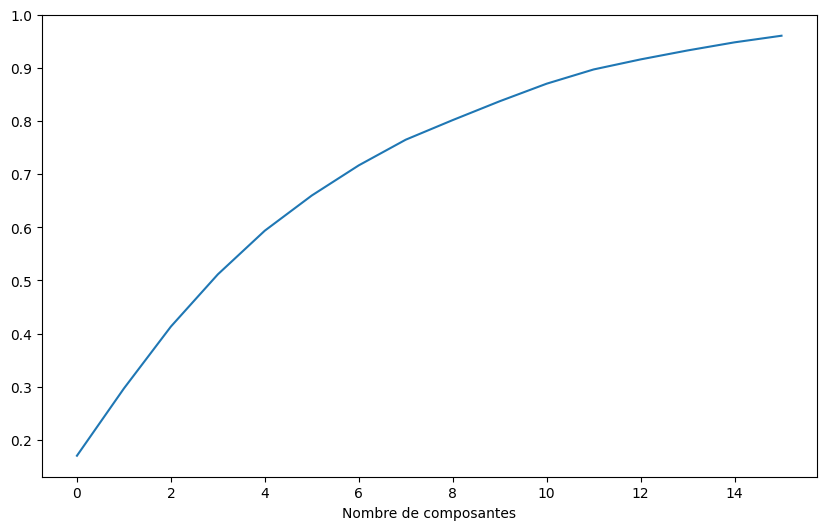

In [10]:
# PCA
pca = PCA(n_components=0.95, random_state=42)

features_pca = pca.fit_transform(features_scaled_df)
print("Nombre de composantes après PCA :", pca.n_components_)

# plot de la variance expliquée
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Nombre de composantes')

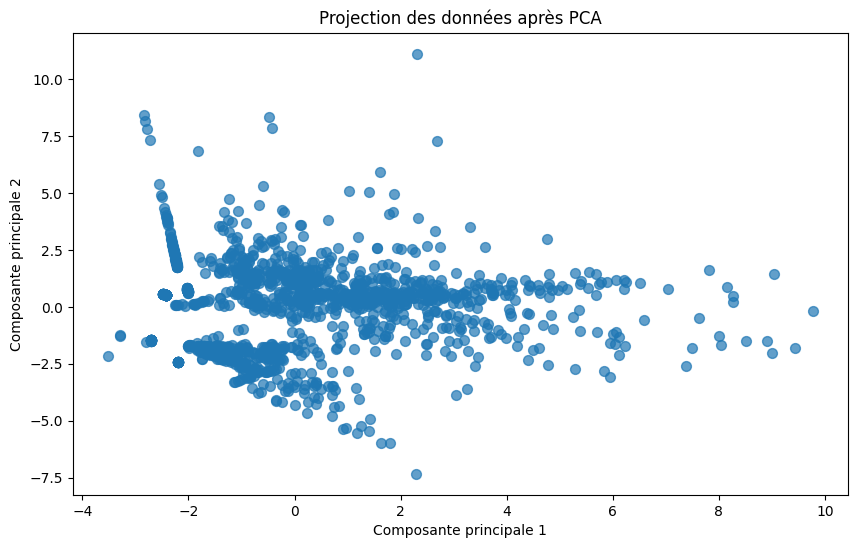

In [45]:
# plot de l'ACP avec les 2 premières composantes
plt.figure(figsize=(10, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], s=50, alpha=0.7)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Projection des données après PCA')
plt.show()

Nombre optimal de composantes : 16
Variance expliquée : 0.9604882142557214


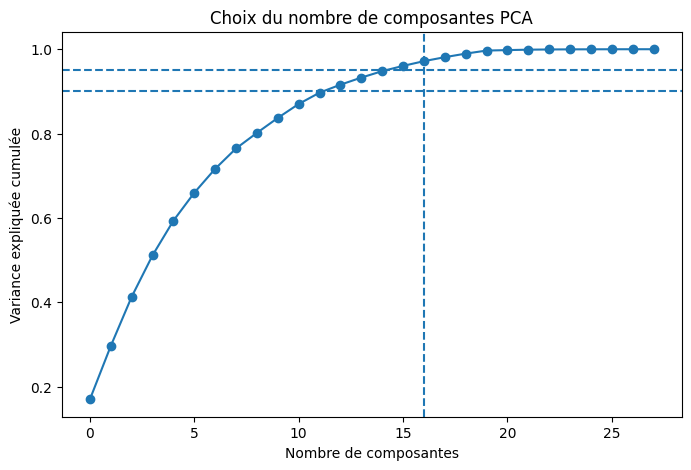

In [46]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# PCA complète
pca = PCA(random_state=42)
pca.fit(features_scaled_df)

# variance expliquée cumulée
cum_var = np.cumsum(pca.explained_variance_ratio_)

threshold = 0.95

n_components = np.argmax(cum_var >= threshold) + 1

print("Nombre optimal de composantes :", n_components)
print("Variance expliquée :", cum_var[n_components-1])

plt.figure(figsize=(8,5))

plt.plot(cum_var, marker='o')
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.axvline(n_components, linestyle='--')

plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Choix du nombre de composantes PCA")

plt.show()

In [47]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

In [48]:
clusterer.fit(features_pca)
labels = clusterer.labels_

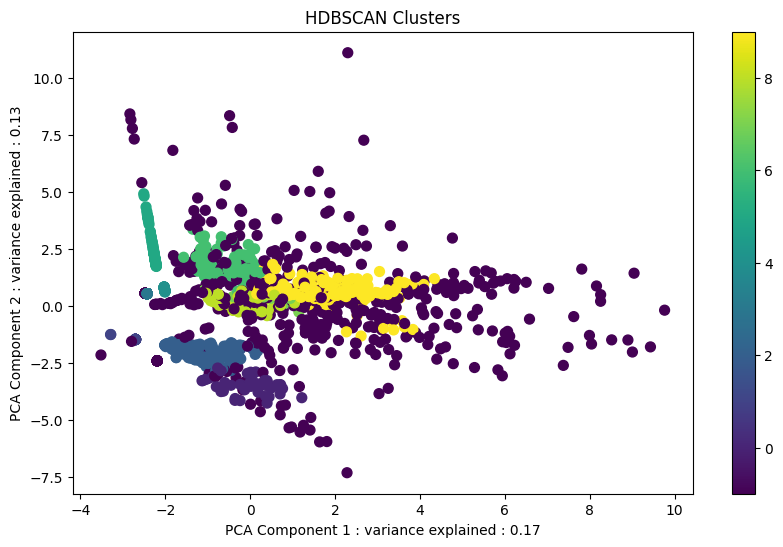

In [49]:
# plotting the clusters
plt.figure(figsize=(10, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels, cmap="viridis", s=50)
plt.colorbar()
plt.title("HDBSCAN Clusters")
plt.xlabel(f"PCA Component 1 : variance explained : {pca.explained_variance_ratio_[0]:.2f}")
plt.ylabel(f"PCA Component 2 : variance explained : {pca.explained_variance_ratio_[1]:.2f}")
plt.show()

Text(0.5, 1.0, 'HDBSCAN Clusters with Noise')

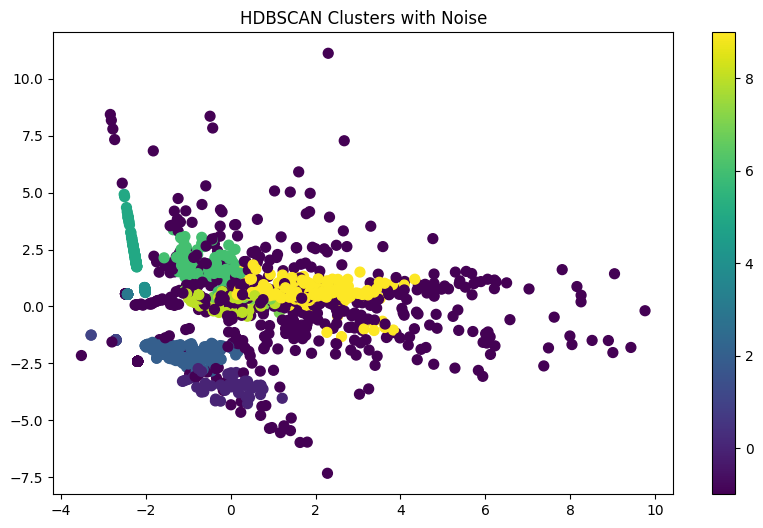

In [50]:
# plot HDBSCAN clusters with noise points in gray
plt.figure(figsize=(10, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels, cmap="viridis", s=50)
plt.colorbar()
plt.title("HDBSCAN Clusters with Noise")

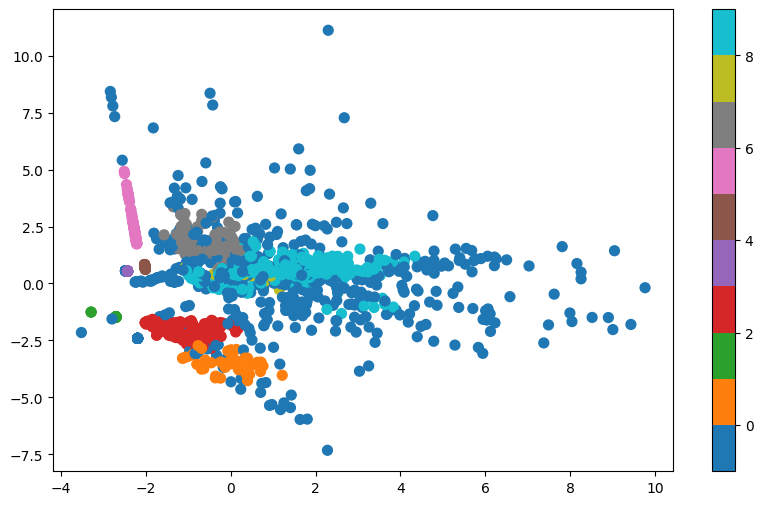

In [51]:
# plot des différents clusters sans gradient de couleur
# on convertit en int les labels pour avoir des couleurs distinctes
labels_int = labels.astype(int)
plt.figure(figsize=(10, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels_int, cmap="tab10", s=50)
plt.colorbar()

Text(0.5, 1.0, 'KMeans Clusters')

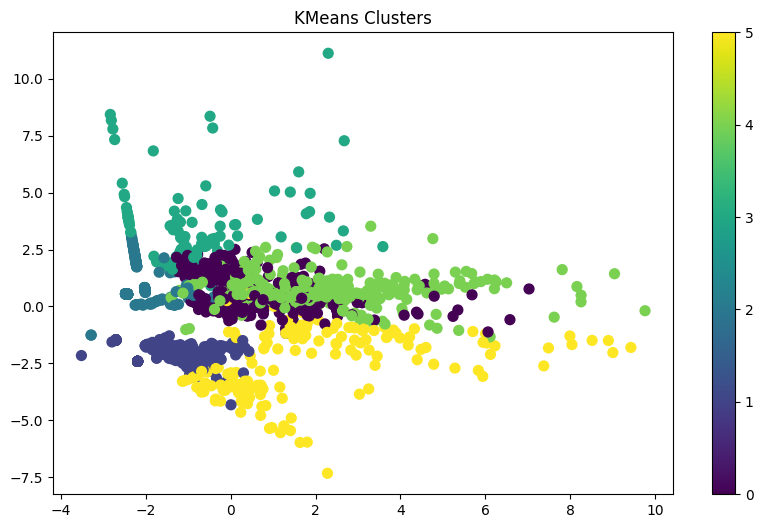

In [52]:
# kmeans à la place de HDBSCAN
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(features_pca)

labels_kmeans = kmeans.labels_
plt.figure(figsize=(10, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels_kmeans, cmap="viridis", s=50)
plt.colorbar()
plt.title("KMeans Clusters")

Text(0.5, 1.0, 'HDBSCAN Clusters Tuned')

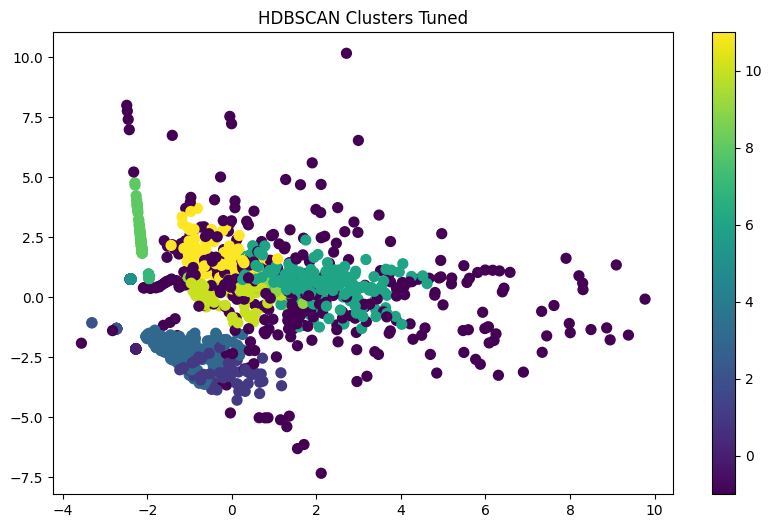

In [20]:
# fine tuning du HDBSCAN
clusterer_tuned = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
clusterer_tuned.fit(features_pca)
labels_tuned = clusterer_tuned.labels_

plt.figure(figsize=(10, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels_tuned, cmap="viridis", s=50)
plt.colorbar()
plt.title("HDBSCAN Clusters Tuned")

In [21]:
for min_cluster_size in [10,15,20,30]:
    for min_samples in [1,3,5,10]:
        
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples
        )
        
        labels = clusterer.fit_predict(features_pca)
        noise = np.mean(labels == -1)

        print(f"min_cluster_size: {min_cluster_size}, min_samples: {min_samples}, noise: {noise:.2f}")

min_cluster_size: 10, min_samples: 1, noise: 0.19
min_cluster_size: 10, min_samples: 3, noise: 0.21
min_cluster_size: 10, min_samples: 5, noise: 0.25
min_cluster_size: 10, min_samples: 10, noise: 0.33
min_cluster_size: 15, min_samples: 1, noise: 0.20
min_cluster_size: 15, min_samples: 3, noise: 0.22
min_cluster_size: 15, min_samples: 5, noise: 0.26
min_cluster_size: 15, min_samples: 10, noise: 0.33
min_cluster_size: 20, min_samples: 1, noise: 0.20
min_cluster_size: 20, min_samples: 3, noise: 0.22
min_cluster_size: 20, min_samples: 5, noise: 0.28
min_cluster_size: 20, min_samples: 10, noise: 0.33
min_cluster_size: 30, min_samples: 1, noise: 0.25
min_cluster_size: 30, min_samples: 3, noise: 0.27
min_cluster_size: 30, min_samples: 5, noise: 0.31
min_cluster_size: 30, min_samples: 10, noise: 0.37


n_clusters: 2, inertia: 35140.33
n_clusters: 2, silhouette_score: 0.18
n_clusters: 3, inertia: 31219.87
n_clusters: 3, silhouette_score: 0.19
n_clusters: 4, inertia: 28755.85
n_clusters: 4, silhouette_score: 0.19
n_clusters: 5, inertia: 27476.50
n_clusters: 5, silhouette_score: 0.20
n_clusters: 6, inertia: 25373.02
n_clusters: 6, silhouette_score: 0.22
n_clusters: 7, inertia: 22574.35
n_clusters: 7, silhouette_score: 0.24
n_clusters: 8, inertia: 20914.92
n_clusters: 8, silhouette_score: 0.24
n_clusters: 9, inertia: 19051.80
n_clusters: 9, silhouette_score: 0.26
n_clusters: 10, inertia: 17660.42
n_clusters: 10, silhouette_score: 0.26


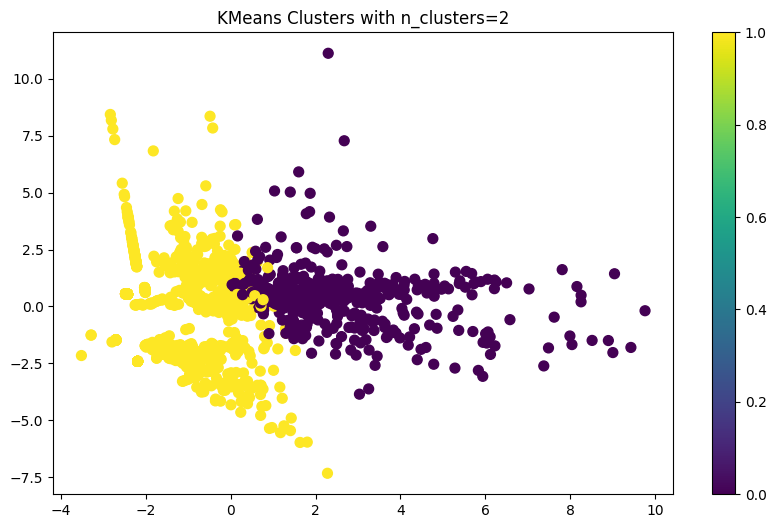

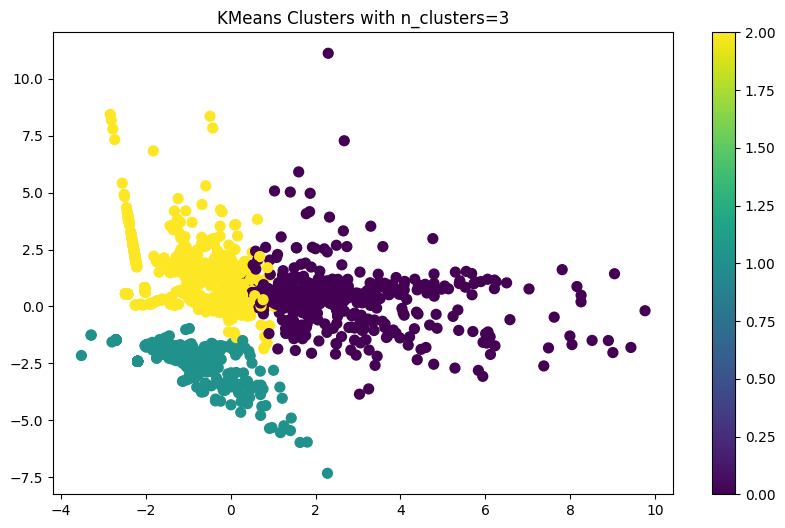

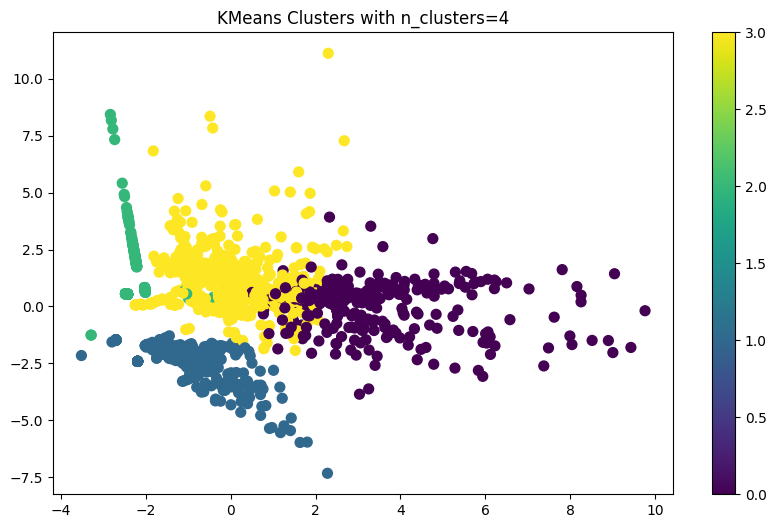

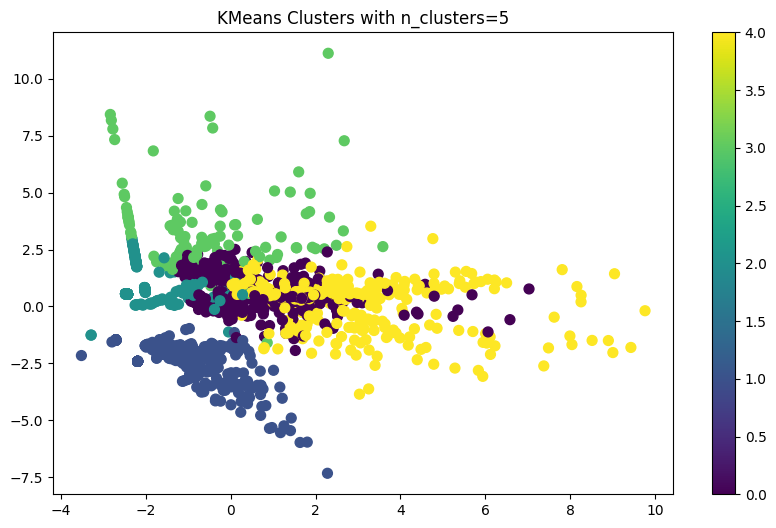

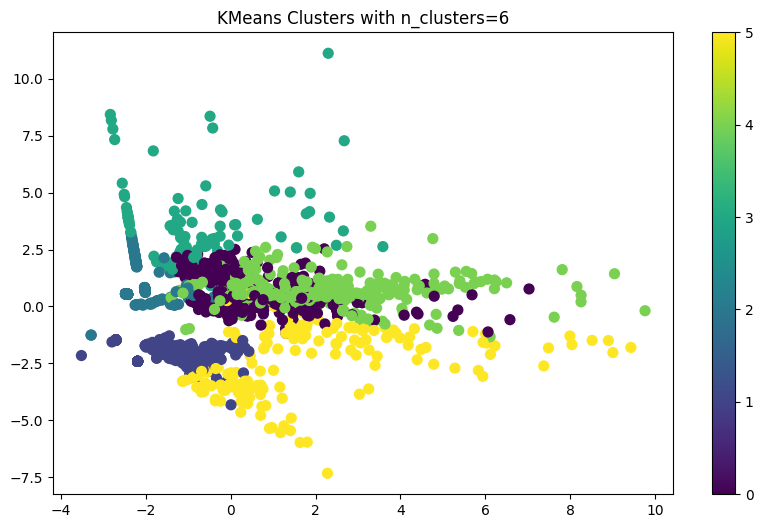

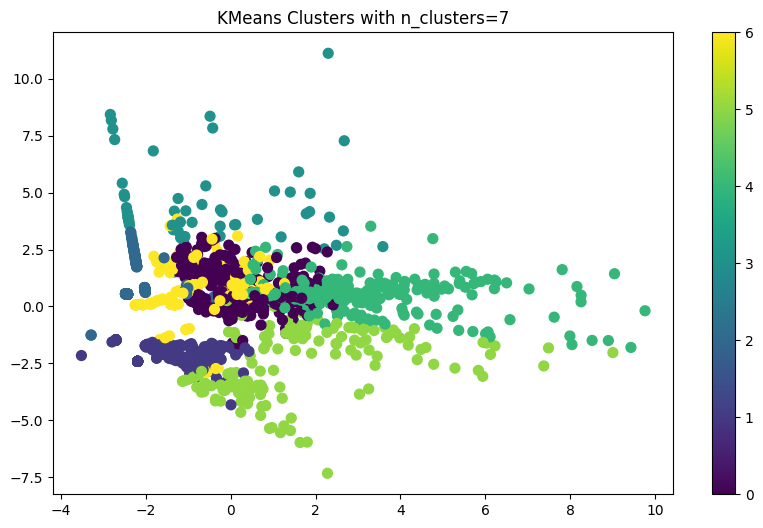

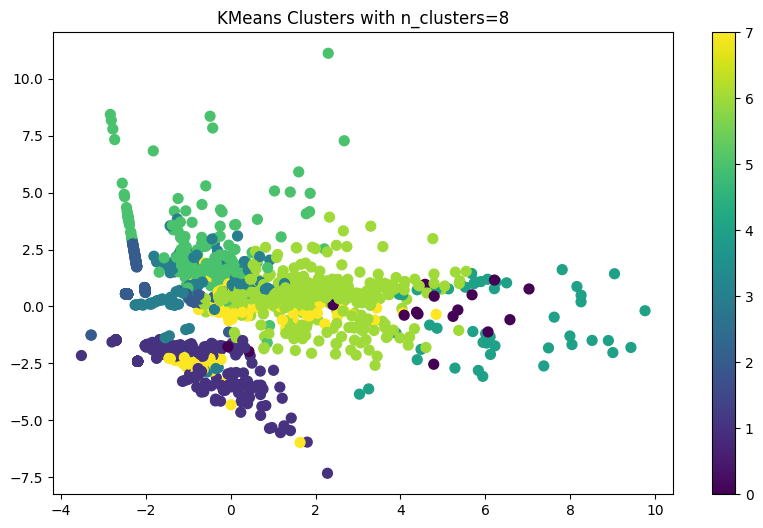

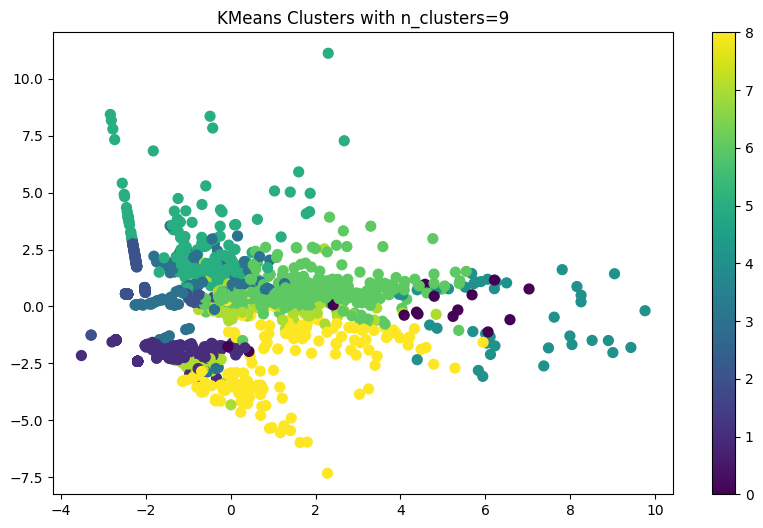

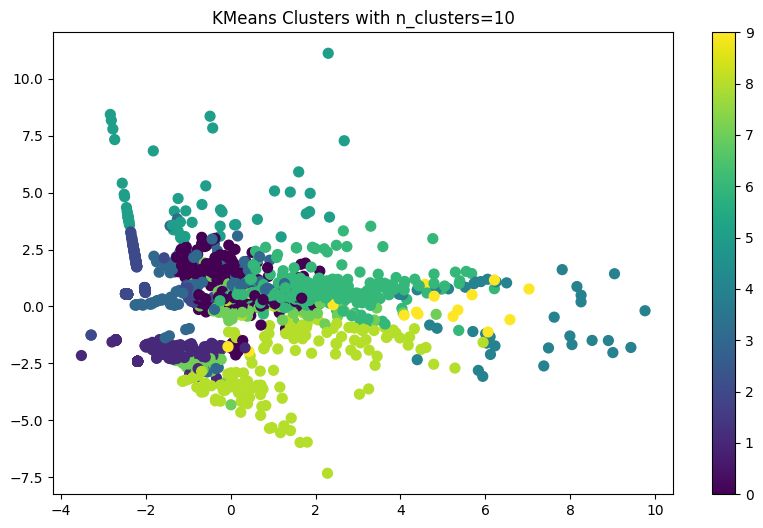

In [53]:
# fine tuning kmeans
from sklearn.metrics import silhouette_score


for n_clusters in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(features_pca)
    labels_kmeans = kmeans.labels_
    # transformation en int pour avoir des couleurs distinctes
    plt.figure(figsize=(10, 6))
    plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels_kmeans, cmap="viridis", s=50)
    plt.colorbar()
    plt.title(f"KMeans Clusters with n_clusters={n_clusters}")
    # stats :
    print(f"n_clusters: {n_clusters}, inertia: {kmeans.inertia_:.2f}")
    print(f"n_clusters: {n_clusters}, silhouette_score: {silhouette_score(features_pca, labels_kmeans):.2f}")

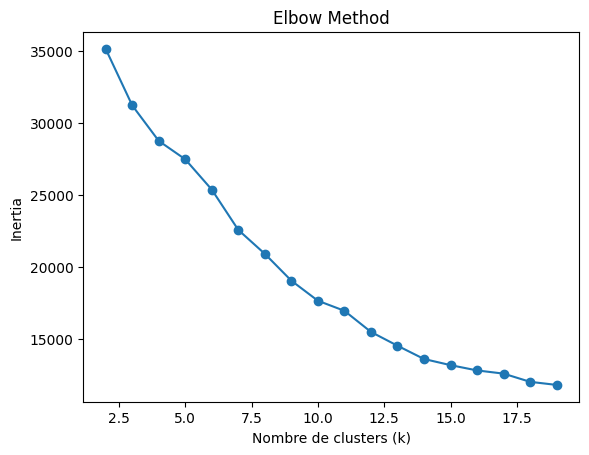

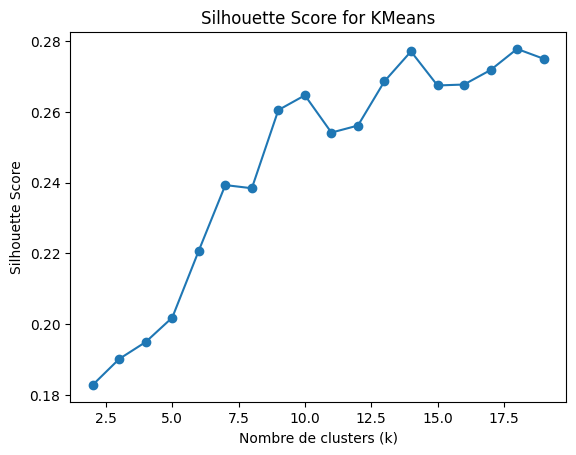

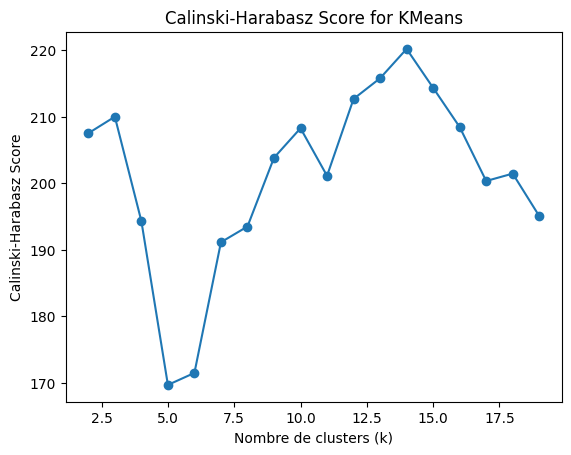

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score

import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []
calinski_harabasz_scores = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_pca)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(features_pca, kmeans.labels_)
    silhouette_scores.append(score)
    score = calinski_harabasz_score(features_pca, kmeans.labels_)
    calinski_harabasz_scores.append(score)

plt.plot(K, inertias, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for KMeans")
plt.show()
plt.plot(K, calinski_harabasz_scores, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score for KMeans")
plt.show()

# df des stats pour chaque k
stats_df = pd.DataFrame({
    "k": K,
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
    "calinski_harabasz_score": calinski_harabasz_scores
})

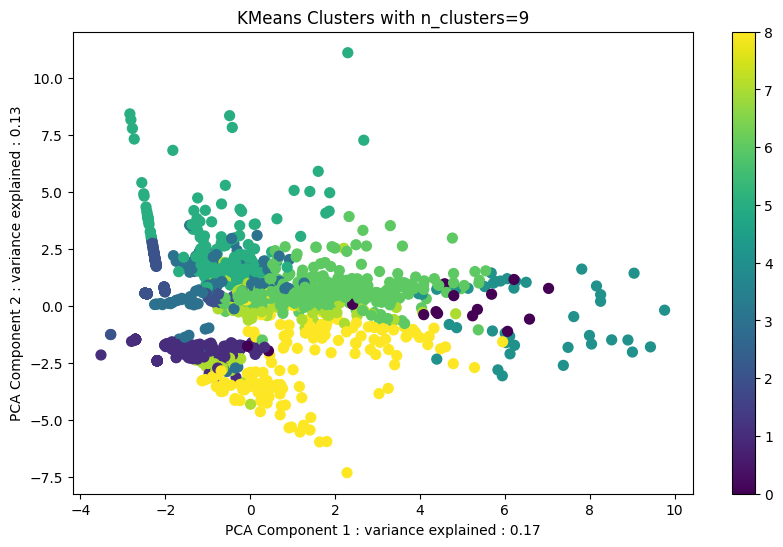

In [62]:
# graph avec 9 clusters 
plt.figure(figsize=(10, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=KMeans(n_clusters=9, random_state=42).fit_predict(features_pca), cmap="viridis", s=50)
plt.colorbar()
plt.title("KMeans Clusters with n_clusters=9")
plt.xlabel(f"PCA Component 1 : variance explained : {pca.explained_variance_ratio_[0]:.2f}")
plt.ylabel(f"PCA Component 2 : variance explained : {pca.explained_variance_ratio_[1]:.2f}")
plt.show()

In [63]:
# same graph in 3d w plotly and saved in html named "3d_9_clusters"
import plotly.express as px

fig = px.scatter_3d(
    x=features_pca[:, 0],
    y=features_pca[:, 1],
    z=features_pca[:, 2],
    color=KMeans(n_clusters=9, random_state=42).fit_predict(features_pca),
    title="KMeans Clusters with n_clusters=9 in 3D",
    labels={
        "x": f"PCA Component 1 : variance explained : {pca.explained_variance_ratio_[0]:.2f}",
        "y": f"PCA Component 2 : variance explained : {pca.explained_variance_ratio_[1]:.2f}",
        "z": f"PCA Component 3 : variance explained : {pca.explained_variance_ratio_[2]:.2f}"
    }
)
fig.write_html("3d_9_clusters.html")

In [64]:
# même graph en 3d mais avec 6 clusters

fig = px.scatter_3d(
    x=features_pca[:, 0],
    y=features_pca[:, 1],
    z=features_pca[:, 2],
    color=KMeans(n_clusters=6, random_state=42).fit_predict(features_pca),
    title="KMeans Clusters with n_clusters=6 in 3D",
    labels={
        "x": f"PCA Component 1 : variance explained : {pca.explained_variance_ratio_[0]:.2f}",
        "y": f"PCA Component 2 : variance explained : {pca.explained_variance_ratio_[1]:.2f}",
        "z": f"PCA Component 3 : variance explained : {pca.explained_variance_ratio_[2]:.2f}"
    }
)
fig.write_html("3d_6_clusters.html")

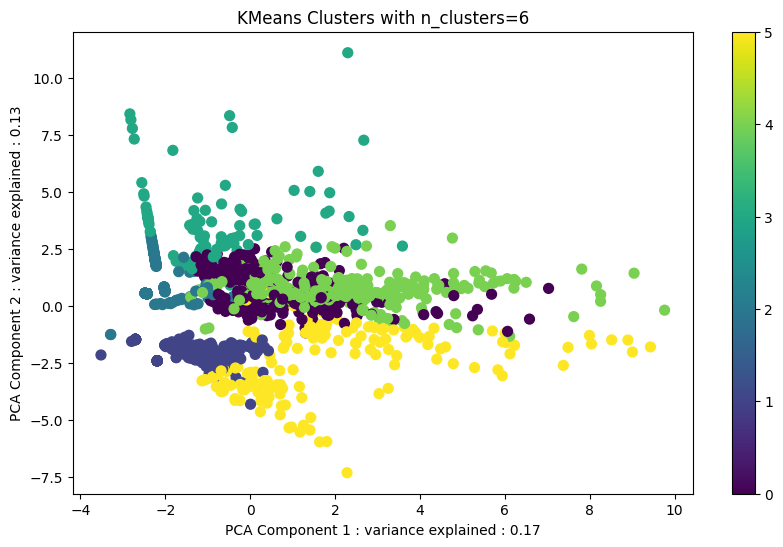

In [65]:
# 6 clusters en 2d
plt.figure(figsize=(10, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=KMeans(n_clusters=6, random_state=42).fit_predict(features_pca), cmap="viridis", s=50)
plt.colorbar()
plt.title("KMeans Clusters with n_clusters=6")
plt.xlabel(f"PCA Component 1 : variance explained : {pca.explained_variance_ratio_[0]:.2f}")
plt.ylabel(f"PCA Component 2 : variance explained : {pca.explained_variance_ratio_[1]:.2f}")
plt.show()

In [67]:
# modèle retenu : 6 pour nb clusters, 16 pour nb composantes PCA, StandardScaler pour la standardisation
# sauvegarde de tous dans le dossier "models" avec joblib
pca_final = PCA(n_components=16, random_state=42)
pca_final.fit(features_scaled_df)
kmeans_final = KMeans(n_clusters=6, random_state=42)
kmeans_final.fit(pca_final.transform(features_scaled_df))
dump(pca_final, "data/models/pca_final.joblib")
dump(kmeans_final, "data/models/kmeans_final.joblib")
dump(scaler, "data/models/scaler_final.joblib")

['data/models/scaler_final.joblib']

In [12]:
# modèle retenu : PCA avec 16 composantes et Kmeans avec 4 clusters
# export des modèles PCA et KMeans mais d'abord création et entrainement
pca_final = PCA(n_components=16, random_state=42)
pca_final.fit(features_scaled_df)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",16
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [16]:
kmeans_final = KMeans(n_clusters=4, random_state=42)
kmeans_final.fit(pca_final.transform(features_scaled_df))

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [32]:
# export des modèles
dump(pca_final, "pca_final.joblib")
dump(kmeans_final, "kmeans_final.joblib")

['kmeans_final.joblib']

In [33]:
# graph 3d des 3 premières composantes de la PCA avec plotly et exporté en html
import plotly.express as px
features_pca_3d = pca_final.transform(features_scaled_df)[:, :3]
fig = px.scatter_3d(
    x=features_pca_3d[:, 0],
    y=features_pca_3d[:, 1],
    z=features_pca_3d[:, 2],
    color=kmeans_final.labels_,
    title="Projection 3D des données après PCA",
    labels={"x": "Composante principale 1", "y": "Composante principale 2", "z": "Composante principale 3"}
)
fig.write_html("pca_3d.html")

In [34]:
# sauvegarde du scaler
dump(scaler, "scaler.joblib")

['scaler.joblib']

In [ ]:
# pipeline de projection d'un point dans l'espace PCA et prédiction du cluster avec KMeans
def predict_cluster(point):
    # retourne le label, et la position dans l'espace PCA 2d
    point_scaled = scaler.transform([point])
    point_pca = pca_final.transform(point_scaled)
    cluster = kmeans_final.predict(point_pca)
    return cluster[0], point_pca[0, 0], point_pca[0, 1]

# Save model

In [ ]:
train_labels = 
print(train_labels.shape)

(1489,)


In [18]:
features_pca.shape

(1489, 16)

In [ ]:
first_two = features_pca[:, :2]              # shape: (1489, 2)
labels_col = kmeans_final.labels_ .reshape(-1, 1)     # shape: (1489, 1)

labeled_data = np.hstack([first_two, labels_col])  # shape: (1489, 3)
np.save("labeled_data.npy", labeled_data)